<a href="https://colab.research.google.com/github/200612780/AIDI1002/blob/main/Project_Smart_Health_%26_Lifestyle_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TODO: Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Activity Part 1 — Load & Explore Dataset

In [2]:
# TODO: Upload dataset from your computer
from google.colab import files
uploaded = files.upload()

Saving project_health_dataset.csv to project_health_dataset.csv


In [3]:
# TODO 1: Load dataset
df = pd.read_csv("project_health_dataset.csv")

In [4]:
# TODO 2: Preview dataset
print(df.head())


   Age  Gender  HoursExercise  HoursSleep  DietScore  StressLevel   BMI  \
0   56    Male             13           5          7            3  18.9   
1   46  Female              4           4          1            5  34.3   
2   32  Female              0           7          3            6  32.4   
3   25  Female              2           7          2            9  24.0   
4   38    Male              9           4          9            5  34.3   

   HealthScore  
0            0  
1            0  
2            1  
3            1  
4            0  


In [5]:
# TODO 3: Dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            100 non-null    int64  
 1   Gender         100 non-null    object 
 2   HoursExercise  100 non-null    int64  
 3   HoursSleep     100 non-null    int64  
 4   DietScore      100 non-null    int64  
 5   StressLevel    100 non-null    int64  
 6   BMI            100 non-null    float64
 7   HealthScore    100 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 6.4+ KB
None


In [6]:
# TODO 3: Missing values
print(df.isnull().sum())

Age              0
Gender           0
HoursExercise    0
HoursSleep       0
DietScore        0
StressLevel      0
BMI              0
HealthScore      0
dtype: int64


In [7]:
# TODO 3: Check duplicates
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [8]:
# TODO 4: Statistical summary
print(df.describe())

              Age  HoursExercise  HoursSleep   DietScore  StressLevel  \
count  100.000000     100.000000  100.000000  100.000000   100.000000   
mean    37.910000       5.990000    6.630000    5.910000     5.280000   
std     12.219454       4.347285    1.778974    3.025464     3.101254   
min     18.000000       0.000000    4.000000    1.000000     1.000000   
25%     26.750000       2.000000    5.000000    3.000000     3.000000   
50%     38.000000       6.000000    7.000000    6.000000     5.000000   
75%     46.250000      10.000000    8.000000    8.250000     8.000000   
max     59.000000      14.000000    9.000000   10.000000    10.000000   

              BMI  HealthScore  
count  100.000000   100.000000  
mean    26.728000     0.420000  
std      4.965804     0.496045  
min     18.500000     0.000000  
25%     22.375000     0.000000  
50%     26.200000     0.000000  
75%     30.775000     1.000000  
max     34.900000     1.000000  


Activity Part 2 — Data Cleaning & Feature Engineering

In [9]:
# TODO 5: Fill missing numerical values with mean
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].mean())

# TODO 6: Fill missing categorical values with mode
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

# TODO 7: Remove duplicate rows
df = df.drop_duplicates()

print("Missing values after cleaning:\n", df.isnull().sum())
print("Duplicates after cleaning:", df.duplicated().sum())

Missing values after cleaning:
 Age              0
Gender           0
HoursExercise    0
HoursSleep       0
DietScore        0
StressLevel      0
BMI              0
HealthScore      0
dtype: int64
Duplicates after cleaning: 0


In [10]:
# TODO 8: Feature Engineering
# WellnessIndex
df['WellnessIndex'] = df['HoursExercise'] * df['HoursSleep']

# BMI Category
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# TODO 9: Encode categorical variables
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['BMI_Category'] = le.fit_transform(df['BMI_Category'])

Activity Part 3 — Data Visualization

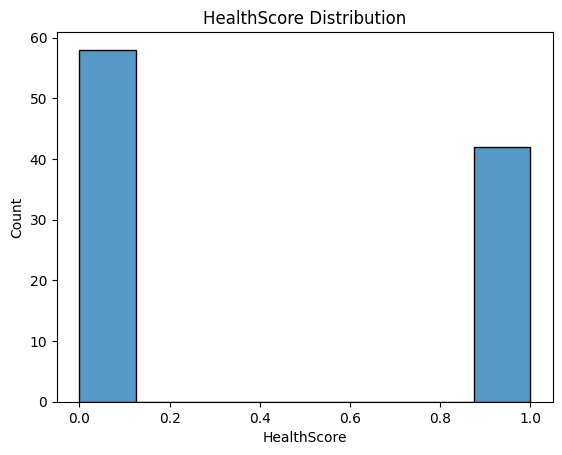

In [11]:
# TODO 10: Histogram of HealthScore
sns.histplot(df['HealthScore'])
plt.title("HealthScore Distribution")
plt.show()

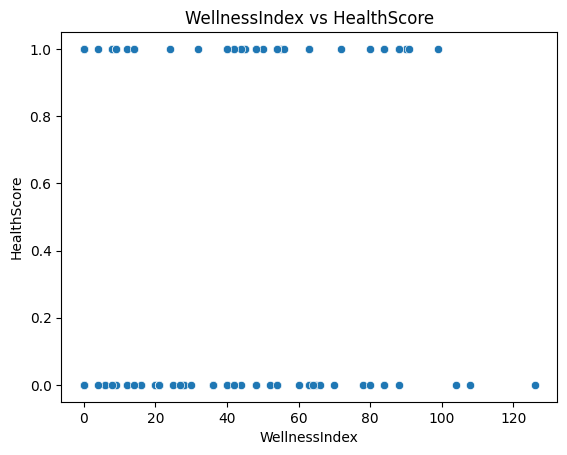

In [12]:
# TODO 11: WellnessIndex vs HealthScore
sns.scatterplot(x='WellnessIndex', y='HealthScore', data=df)
plt.title("WellnessIndex vs HealthScore")
plt.show()

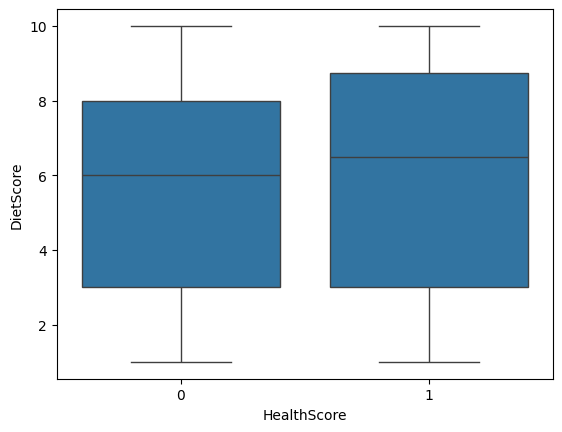

In [13]:
# TODO 12: DietScore vs HealthScore
sns.boxplot(x='HealthScore', y='DietScore', data=df)
plt.show()

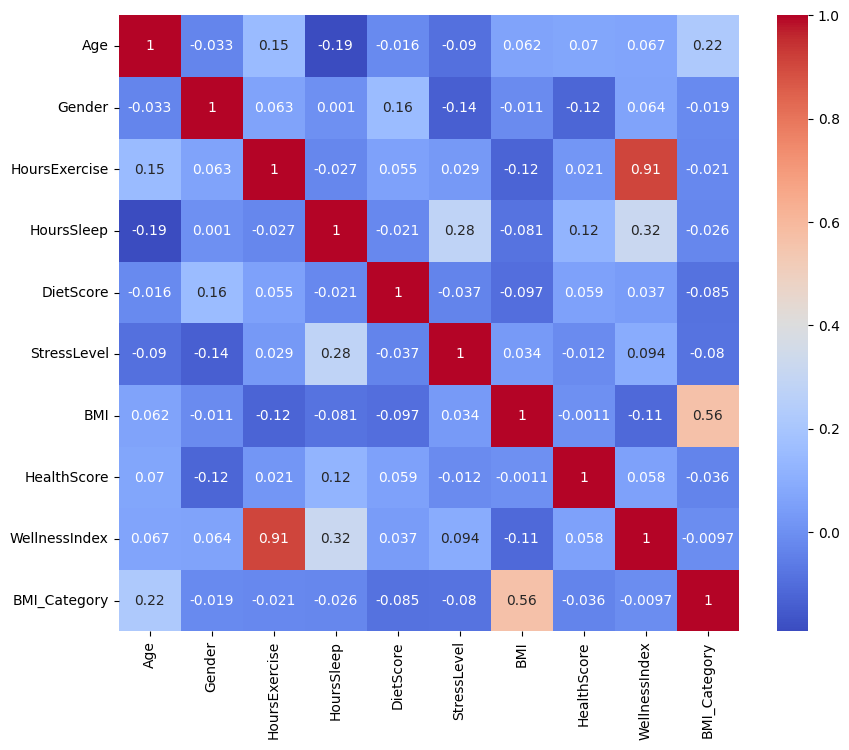

In [14]:
# TODO 13: Heatmap of feature correlations
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

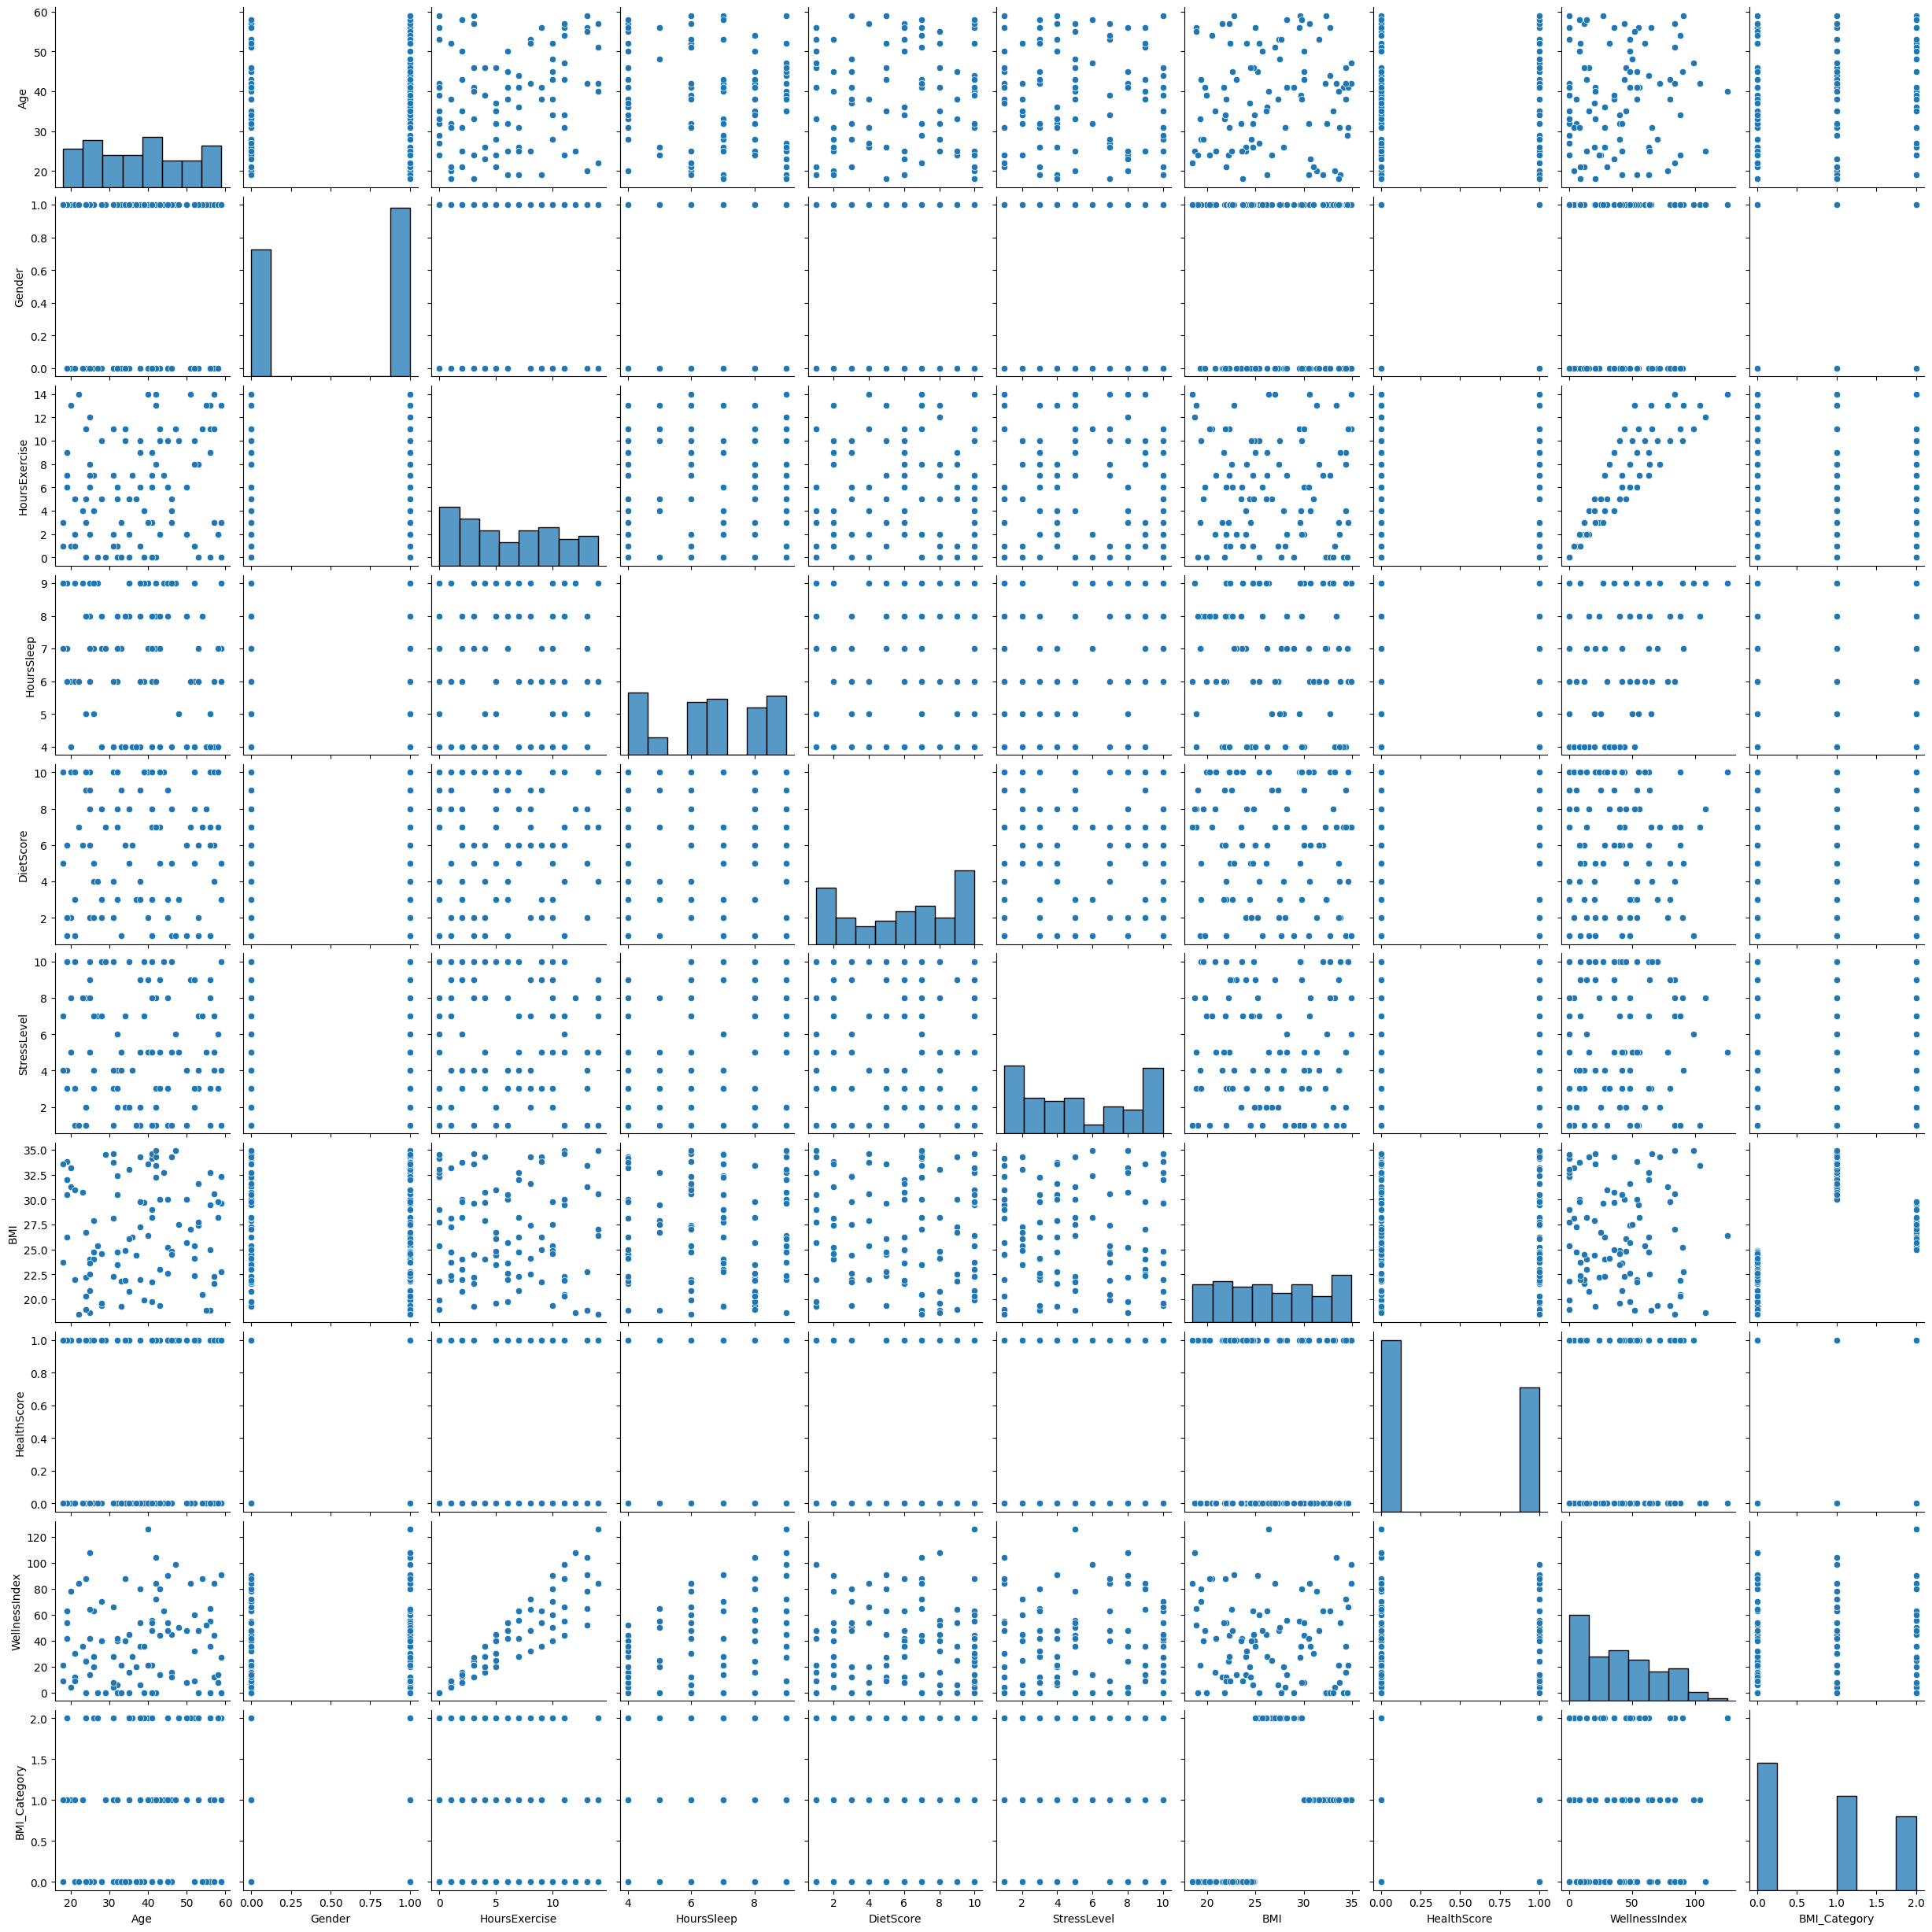

In [15]:
# TODO 14: Pairwise Feature Relationships
sns.pairplot(df)
plt.show()

Activity Part 4 — Supervised Machine Learning

In [16]:
# TODO 15: Split dataset into X (features) and y (HealthScore)
X = df.drop('HealthScore', axis=1)
y = df['HealthScore']

# TODO 16:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# TODO 17: KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.55
[[8 7]
 [2 3]]
              precision    recall  f1-score   support

           0       0.80      0.53      0.64        15
           1       0.30      0.60      0.40         5

    accuracy                           0.55        20
   macro avg       0.55      0.57      0.52        20
weighted avg       0.68      0.55      0.58        20



In [17]:
# TODO 18: Train Random Forest, Logistic Regression, and SVM models
models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results[name] = (acc, f1)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)

# TODO 19: Compare models using accuracy and F1-score
print("\nModel Comparison:", results)


Random Forest
Accuracy: 0.4
F1 Score: 0.14285714285714285

Logistic Regression
Accuracy: 0.55
F1 Score: 0.3076923076923077

SVM
Accuracy: 0.65
F1 Score: 0.36363636363636365

Model Comparison: {'Random Forest': (0.4, 0.14285714285714285), 'Logistic Regression': (0.55, 0.3076923076923077), 'SVM': (0.65, 0.36363636363636365)}


Activity Part 5 — Neural Network Programming

In [18]:
# TODO 20: Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TODO 21: Build neural network

from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# TODO 22: Train network on training data, validate on test data
history = model.fit(X_train_scaled, y_train, epochs=20, validation_data=(X_test_scaled, y_test))



Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.5875 - loss: 0.6947 - val_accuracy: 0.4500 - val_loss: 0.8141
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6000 - loss: 0.6891 - val_accuracy: 0.4500 - val_loss: 0.8070
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6000 - loss: 0.6848 - val_accuracy: 0.4500 - val_loss: 0.8007
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6000 - loss: 0.6816 - val_accuracy: 0.4500 - val_loss: 0.7934
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6000 - loss: 0.6774 - val_accuracy: 0.4500 - val_loss: 0.7885
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6125 - loss: 0.6740 - val_accuracy: 0.4500 - val_loss: 0.7841
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6000 - loss: 0.6705 - val_accuracy: 0.4500 - val_loss: 0.7810
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6000 - loss: 0.6675 - val_accuracy: 0.4500 - val_loss: 0.7762

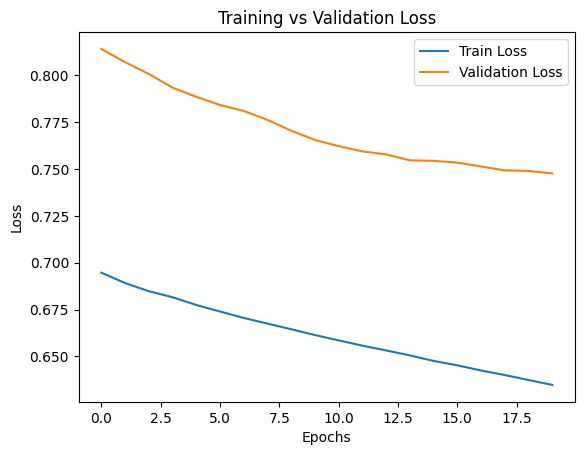

In [28]:
# TODO 23: Plot loss and accuracy curves

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [20]:
# TODO 24: Evaluate predictions using confusion matrix
y_pred_nn = (model.predict(X_test_scaled) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred_nn))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[7 8]
 [3 2]]


Activity Part 6 — K-Fold Cross-Validation

In [21]:
# TODO 25: Implement K-Fold (k=5 or 10) on one ML model (e.g., Random Forest)
kf = KFold(n_splits=5)

rf = RandomForestClassifier()
scores = cross_val_score(rf, X, y, cv=kf)

# TODO 26: Record mean accuracy and variance across folds
print("Scores:", scores)
print("Mean:", scores.mean())
print("Variance:", scores.var())

Scores: [0.6  0.5  0.6  0.4  0.35]
Mean: 0.49000000000000005
Variance: 0.010399999999999998


Activity Part 7 — Dimensionality Reduction

In [22]:
# TODO 27: Apply PCA to reduce features to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

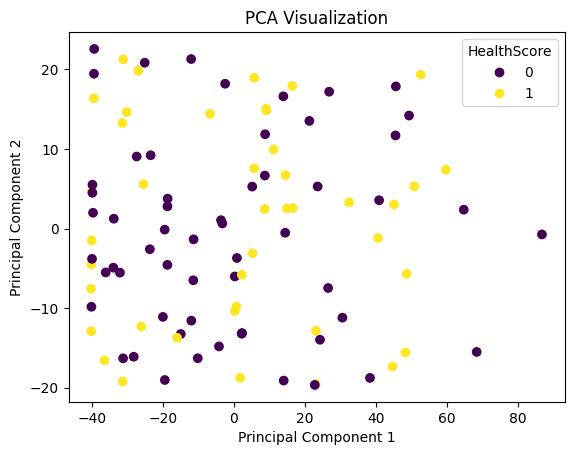

In [26]:
# TODO 28: Visualize first 2 PCA components with color by HealthScore
plt.figure()

scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(*scatter.legend_elements(), title="HealthScore")

plt.show()

In [24]:
# TODO 29: Apply LDA (if supervised) to separate classes
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

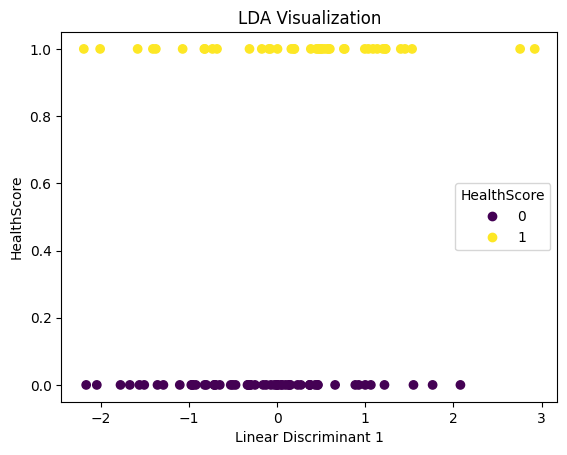

In [27]:
# TODO 30: Compare PCA vs LDA scatter plots
plt.figure()

scatter = plt.scatter(X_lda, y, c=y)

plt.title("LDA Visualization")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("HealthScore")


plt.legend(*scatter.legend_elements(), title="HealthScore")

plt.show()

## Activity Part 8 — Insights & Recommendations

### TODO 31: Observations

- The analysis shows that individuals with a higher **WellnessIndex** (combination of exercise and sleep) tend to have better health outcomes.
- **DietScore** has a positive impact on health, with higher scores associated with healthier individuals.
- **StressLevel** negatively affects health; individuals with higher stress levels are more likely to be classified as unhealthy.
- **BMI** plays a crucial role, where individuals in the normal BMI range are more likely to be healthy, while extreme BMI values correlate with poor health.
- Some features exhibit weak linear relationships, indicating the presence of non-linear patterns in the dataset.



### TODO 32: Model Comparison & Best Model

- Multiple models were trained and evaluated, including **Random Forest, Logistic Regression, and SVM**.
- Among all models, **SVM (Support Vector Machine)** performed the best with the highest **Accuracy (0.65)** and **F1 Score (0.3636)**.
- Random Forest performed the weakest with Accuracy: 0.40 and F1 Score: 0.1429.
- Logistic Regression performed moderately with Accuracy: 0.55 and F1 Score: 0.3077.
- SVM outperformed the others because it:
  - Finds an optimal decision boundary (hyperplane) that maximizes the margin between classes
  - Handles high-dimensional feature spaces effectively
  - Works well even when classes are not linearly separable using kernel tricks
- Overall scores are relatively low, suggesting potential improvements through hyperparameter tuning, feature engineering, or collecting more data.



### TODO 33: Lifestyle Recommendations

Based on the analysis and model predictions, the following lifestyle improvements are recommended:

- Engage in **regular physical activity** to improve overall wellness.
- Maintain **7–8 hours of sleep daily** for optimal health.
- Follow a **balanced and nutritious diet** to improve DietScore.
- Manage and reduce **stress levels** through activities like meditation, exercise, or hobbies.
- Maintain a **healthy BMI range** through proper diet and exercise.
